In [24]:
import os
import sys
import numpy as np
import xarray as xr
import seaborn as sns
import geopandas as gpd
import shapely.vectorized as sv
from scipy.special import gammaln

from scipy.stats import weibull_min
import matplotlib.pyplot as plt

import cartopy.crs as ccrs
import cartopy.feature as cfeature

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import BoundaryNorm

from scipy.special import gamma
from scipy.optimize import fsolve

sys.path.append(os.path.abspath("../.."))
from function import DOWN_raw
from function import ART_downscale

In [25]:
beta_version = 'beta_v2' # Use the beta python code BETA_v2.py - 25/07/2-26

npix = 4

In [26]:
# product, time_reso = 'IMERG', '3h'
# product, time_reso = 'CMORPH', '3h'
# product, time_reso = 'MSWEP', '3h'
# product, time_reso = 'ERA5', '3h'
product, time_reso = 'GSMaP', '3h'
# product, time_reso = 'CHIRPS', '1dy'

In [27]:
lon_min, lon_max, lat_min, lat_max, area = 6.5, 19, 36.5, 48, 'ITALY'

In [28]:
GEOMETRY = gpd.read_file(os.path.join('..','..', 'geometry','Italy_simple.geojson'))
GEOMETRY_geom = GEOMETRY.union_all() # ONLY FOR ITALY

In [29]:
dir_base = os.path.join('/','media','arturo','T9','Data','Italy','Satellite','2_MEV')

In [30]:
dir_data_big = os.path.join(dir_base, 'beta', beta_version, f'ITALY_Beta_{product}_{time_reso}_2002_2023_npix_{npix}.nc')
DATA_big = xr.open_dataset(dir_data_big)

dir_data_small = os.path.join(dir_base,'uncorrected','OLD',f'ITALY_DOWN_{product}_{time_reso}_2002_2023_npix_2_thr_1_acf_mar_genetic_pearson.nc')
DATA_small = xr.open_dataset(dir_data_small)

# recortar el grande usando el rango del pequeño
DATA_big_cut = DATA_big.sel(
    lat=slice(DATA_small.lat.min(), DATA_small.lat.max()),
    lon=slice(DATA_small.lon.min(), DATA_small.lon.max())
)

In [31]:
BETA_new = DATA_big_cut.BETA.values
lon2d2, lat2d2 = np.meshgrid(DATA_big_cut.lon, DATA_big_cut.lat)

In [32]:
lons = DATA_small.lon
lats = DATA_small.lat
lon2d, lat2d = np.meshgrid(lons, lats)
mask_italy = sv.contains(GEOMETRY_geom, lon2d, lat2d)
BETA_old = DATA_small.BETA.where(mask_italy).values
BETA_old = np.where(BETA_old==0,np.nan,BETA_old)
GAMMA = DATA_small.GAMMA.where(mask_italy).values
Mevd_old = DATA_small.Mev_d.where(mask_italy).values

In [33]:
if product == 'CHIRPS':
    print('Applying mask')
    mask_beta = np.isnan(BETA_old)
    BETA_new[mask_beta]  = np.nan

Text(0.0, 1.0, '(c) Beta difference')

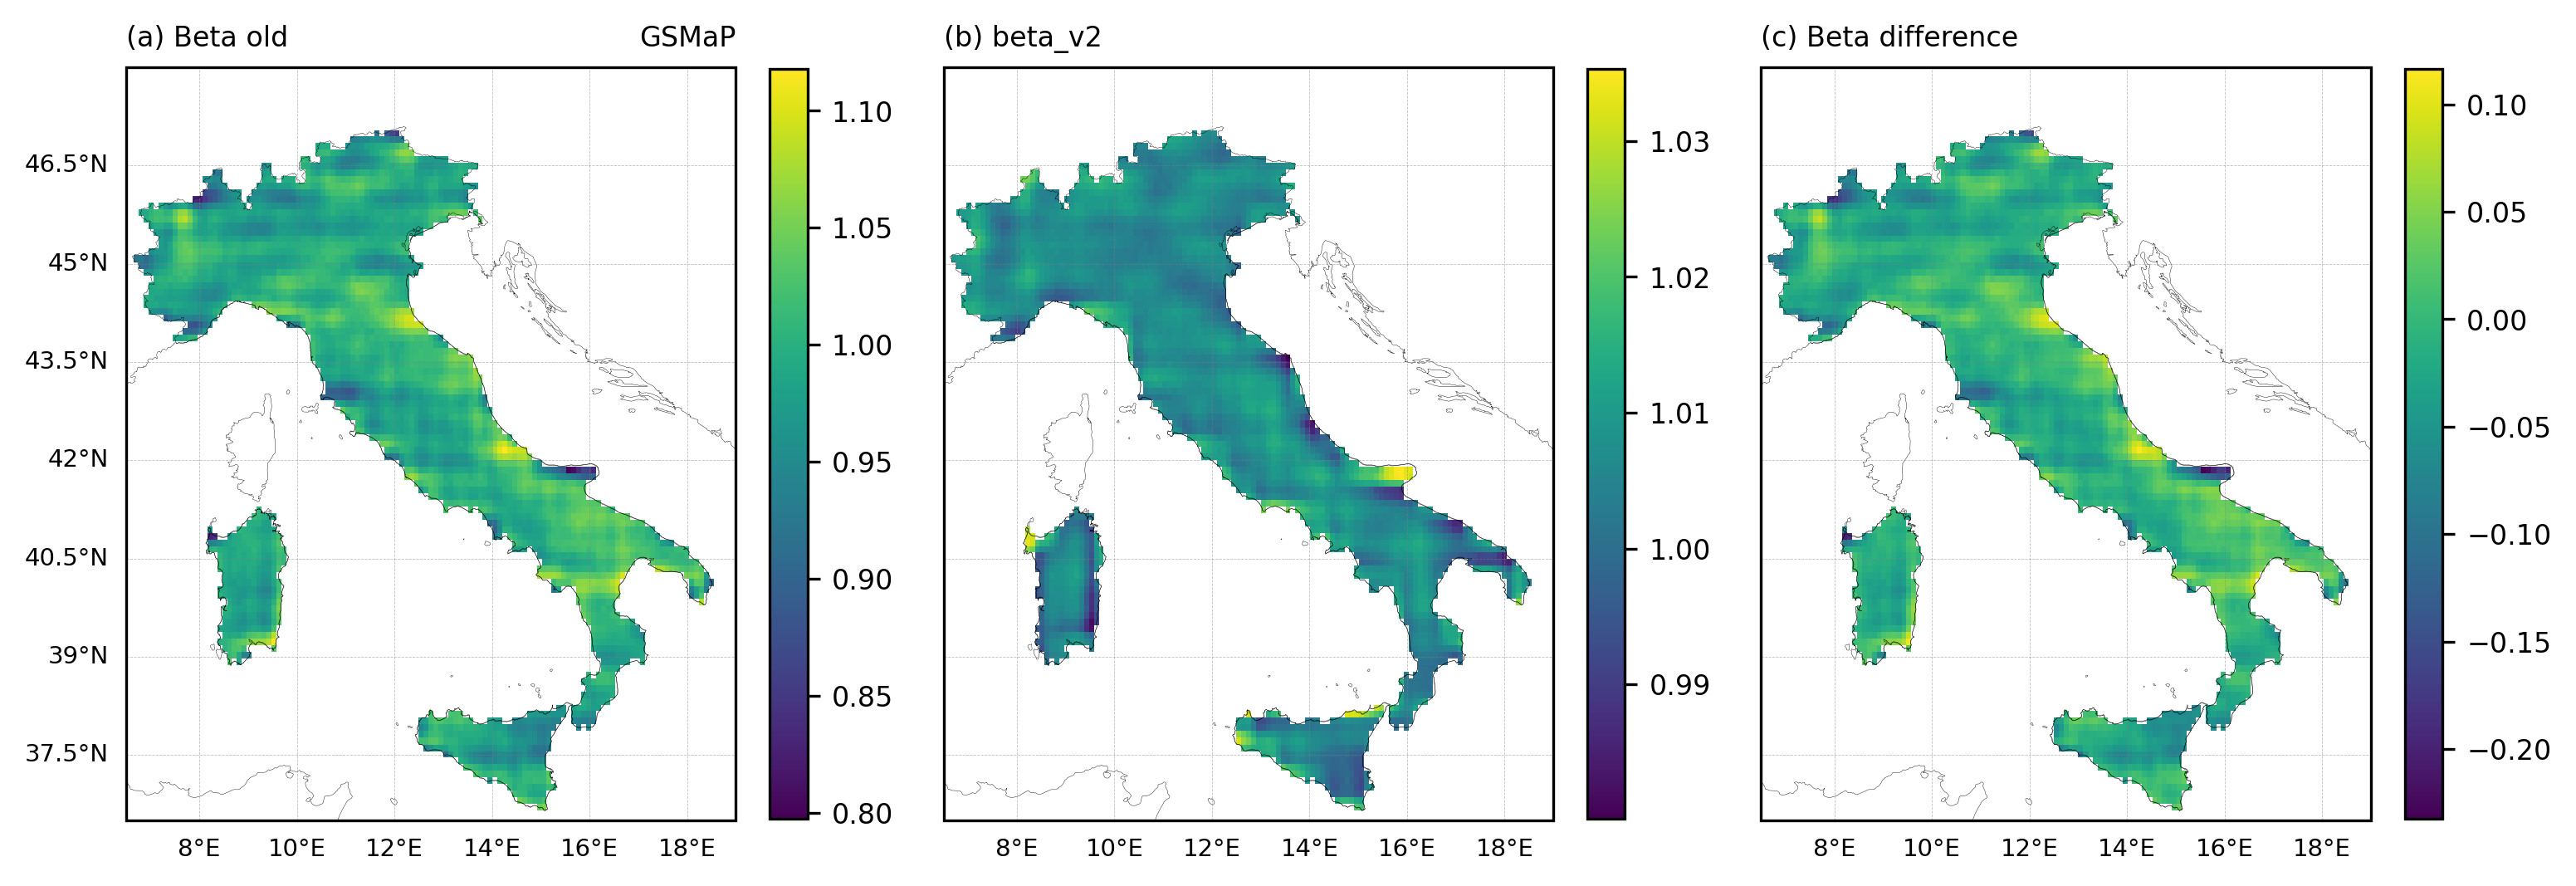

In [34]:
proj = ccrs.PlateCarree()

fig = plt.figure(figsize=(12,4),dpi=300)
gs = gridspec.GridSpec(1,3)

# ========================================================================================================
ax1 = plt.subplot(gs[0, 0], projection = proj)
ax1.set_extent([lon_min, lon_max, lat_min, lat_max], crs=proj)
ax1.add_feature(cfeature.COASTLINE,linewidth=0.1,edgecolor='k')
GEOMETRY.plot(legend=False, facecolor="none", edgecolor='black', linewidth=0.1, ax=ax1, zorder=10)
a1 = ax1.pcolormesh(lon2d, lat2d, BETA_old)
cbar = plt.colorbar(a1, fraction=0.055)
cbar.ax.tick_params(labelsize=8)

gl = ax1.gridlines(crs=proj,draw_labels=True,linewidth=0.2,color='gray',alpha=0.5,linestyle='--')
gl.top_labels = False
gl.bottom_labels = True
gl.left_labels = True
gl.right_labels = False
gl.xlabel_style = {'size': 7, 'color': 'k'}
gl.ylabel_style = {'size': 7, 'color': 'k'}

ax1.set_title('(a) Beta old', fontsize=8, loc='left')
ax1.set_title(product, fontsize=8, loc='right')

# ========================================================================================================
ax1 = plt.subplot(gs[0, 1], projection = proj)
ax1.set_extent([lon_min, lon_max, lat_min, lat_max], crs=proj)
ax1.add_feature(cfeature.COASTLINE,linewidth=0.1,edgecolor='k')
GEOMETRY.plot(legend=False, facecolor="none", edgecolor='black', linewidth=0.1, ax=ax1, zorder=10)
a1 = ax1.pcolormesh(lon2d, lat2d, BETA_new)
cbar = plt.colorbar(a1, fraction=0.055)
cbar.ax.tick_params(labelsize=8)

gl = ax1.gridlines(crs=proj,draw_labels=True,linewidth=0.2,color='gray',alpha=0.5,linestyle='--')
gl.top_labels = False
gl.bottom_labels = True
gl.left_labels = False
gl.right_labels = False
gl.xlabel_style = {'size': 7, 'color': 'k'}
gl.ylabel_style = {'size': 7, 'color': 'k'}

ax1.set_title(f'(b) {beta_version}', fontsize=8, loc='left')

# ========================================================================================================
ax1 = plt.subplot(gs[0, 2], projection = proj)
ax1.set_extent([lon_min, lon_max, lat_min, lat_max], crs=proj)
ax1.add_feature(cfeature.COASTLINE,linewidth=0.1,edgecolor='k')
GEOMETRY.plot(legend=False, facecolor="none", edgecolor='black', linewidth=0.1, ax=ax1, zorder=10)
a1 = ax1.pcolormesh(lon2d, lat2d, BETA_old-BETA_new)
cbar = plt.colorbar(a1, fraction=0.055)
cbar.ax.tick_params(labelsize=8)

gl = ax1.gridlines(crs=proj,draw_labels=True,linewidth=0.2,color='gray',alpha=0.5,linestyle='--')
gl.top_labels = False
gl.bottom_labels = True
gl.left_labels = False
gl.right_labels = False
gl.xlabel_style = {'size': 7, 'color': 'k'}
gl.ylabel_style = {'size': 7, 'color': 'k'}

ax1.set_title('(c) Beta difference', fontsize=8, loc='left')

In [35]:
# def downscaling_parameters(Ns, Cs, Ws, bet, gam):
#     m = len(Ns)
#     pws = np.mean(Ns) / 365.25
#     Wd = np.zeros(m)
#     Cd = np.zeros(m)
#     Nd = np.zeros(m)
    
#     for ii in range(m):
#         cs = Cs[ii]
#         ws = Ws[ii]
#         rhs = 1 / bet / gam * (2 * ws * gamma(2 / ws) / ( gamma(1 / ws)) ** 2 + (gam - 1) * pws)
#         wpfun = lambda w: 2 * w * gamma(2 / w) / (gamma(1 / w)) ** 2 - rhs
#         res = fsolve(wpfun, 0.1, full_output=True, xtol=1e-06, maxfev=10000)
#         Wd[ii] = res[0]
#         info = res[1]
#         fval = info['fvec']
#         if fval > 1e-5:
#                 print('warning - downscaling function:: '
#                         'there is something wrong solving fsolve!')
# 
#         Cd[ii] = bet * Wd[ii] * (cs / ws) * gamma(1 / ws) / gamma(1 / Wd[ii])
#         Nd[ii] = int( np.rint( Ns[ii] / bet)) #Nd[ii] = np.int( np.rint( Ns[ii] / beta))
        
#     return Nd, Cd, Wd

In [36]:
Tr = [5,  10,  20,  50, 100, 200]
Fi = 1 - 1/np.array(Tr)

NYd = np.zeros(DATA_small.NYs.shape)
CYd = np.zeros(DATA_small.NYs.shape)
WYd = np.zeros(DATA_small.NYs.shape)
Mevd = np.zeros([6, len(lats), len(lons)])

bet_new = DATA_big_cut.BETA.values

for i in range(len(lats)):
    for j in range(len(lons)):

        Ns = DATA_small.NYs.values[:,i,j]
        Cs = DATA_small.CYs.values[:,i,j]
        Ws = DATA_small.WYs.values[:,i,j]

        if product == 'CHIRPS':
            bet_new[mask_beta] = np.nan
        bet = bet_new[i,j]

        gam = DATA_small.GAMMA.values[i,j]

        if np.isnan(bet) == True:
            NYd[:,i,j] = np.nan
            CYd[:,i,j] = np.nan
            WYd[:,i,j] = np.nan
            Mevd[:,i,j] = np.nan
        else:
            # Nd, Cd, Wd = downscaling_parameters(Ns, Cs, Ws, bet, gam)
            Nd, Cd, Wd = ART_downscale.down_wei_beta_alpha_update_v2(Ns, Cs, Ws, bet, gam)
            NYd[:,i,j] = Nd
            CYd[:,i,j] = Cd
            WYd[:,i,j] = Wd
            
            x0 = 5.0*np.mean(Cd)
            Mev_d_man, _ = ART_downscale.mev_quant_update(Fi, x0, Nd, Cd, Wd)
            Mevd[:,i,j] = Mev_d_man
            # Mevd[:,i,j] = DOWN_raw.mev_quant_update(Fi, x0, Nd, Cd, Wd, thresh=1)[0]

/home/arturo/github/MEVD-downscaling/function/ART_downscale.py:744: RuntimeWarning: invalid value encountered in divide
  wpfun = lambda w: (2*w*gamma(2 / w)/(gamma(1/w))**2) - rhs


In [37]:
pos_x, pos_y = np.where(~np.isnan(DATA_big_cut.BETA.values))

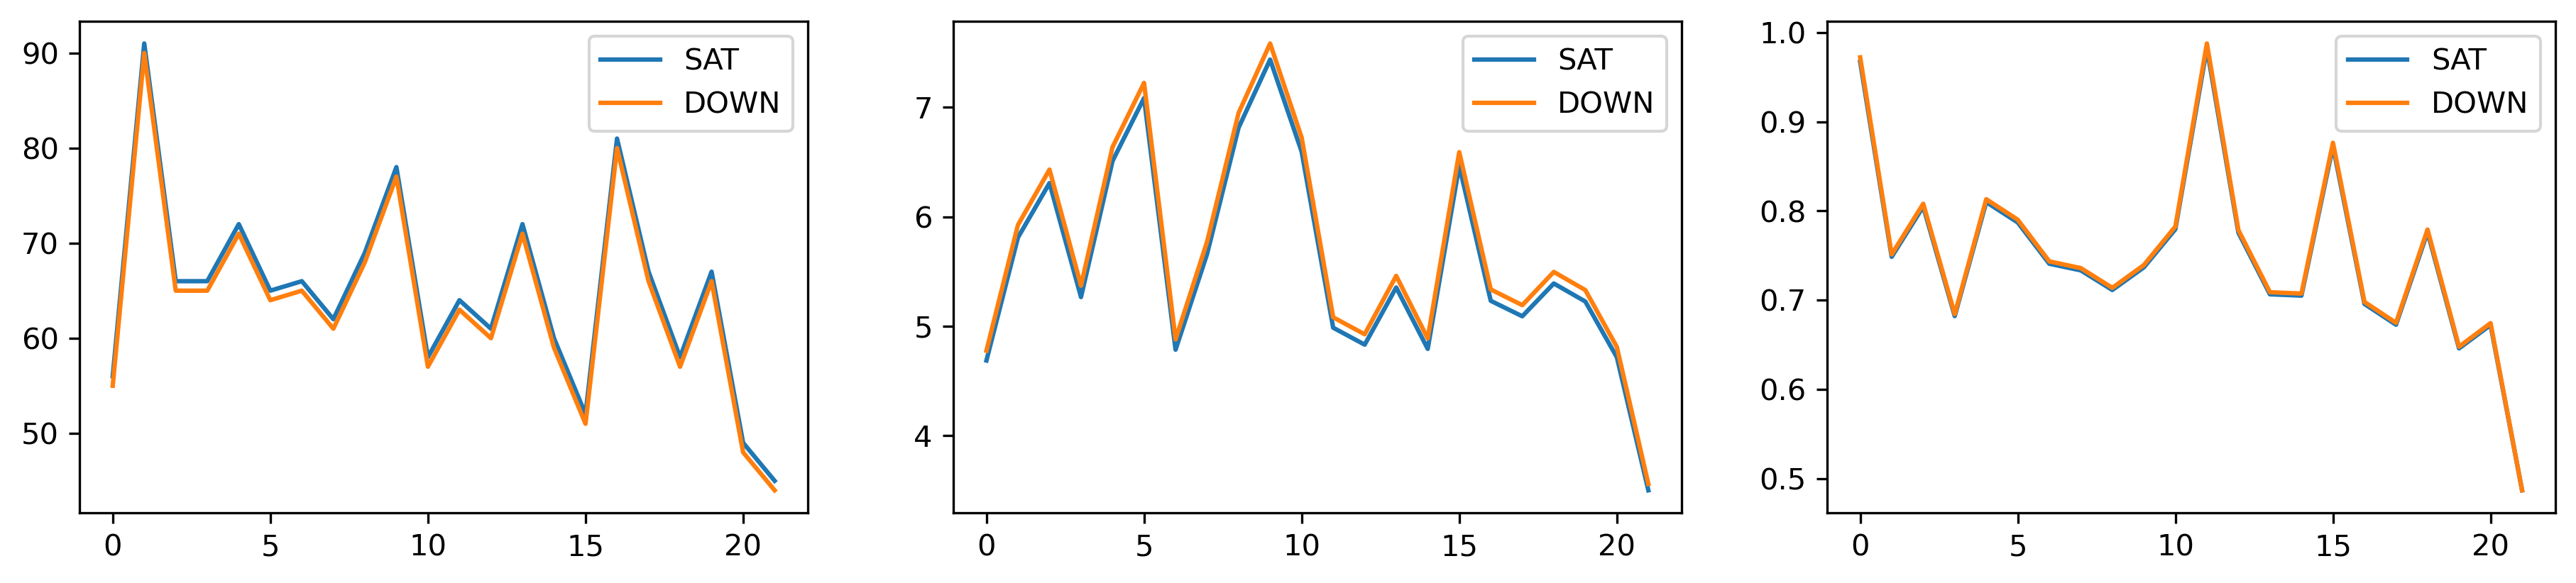

In [38]:
# i,j = 3,80
i,j = pos_x[2],pos_y[3]

fig = plt.figure(figsize=(15,3),dpi=300)
gs = gridspec.GridSpec(1,3)

# ========================================================================================================
ax1 = plt.subplot(gs[0, 0])
ax1.plot(DATA_small.NYs.values[:,i,j], label='SAT')
ax1.plot(NYd[:,i,j], label='DOWN')
ax1.legend()

# ========================================================================================================
ax1 = plt.subplot(gs[0, 1])
ax1.plot(DATA_small.CYs.values[:,i,j], label='SAT')
ax1.plot(CYd[:,i,j], label='DOWN')
ax1.legend()

# ========================================================================================================
ax1 = plt.subplot(gs[0, 2])
ax1.plot(DATA_small.WYs.values[:,i,j], label='SAT')
ax1.plot(WYd[:,i,j], label='DOWN')
ax1.legend()

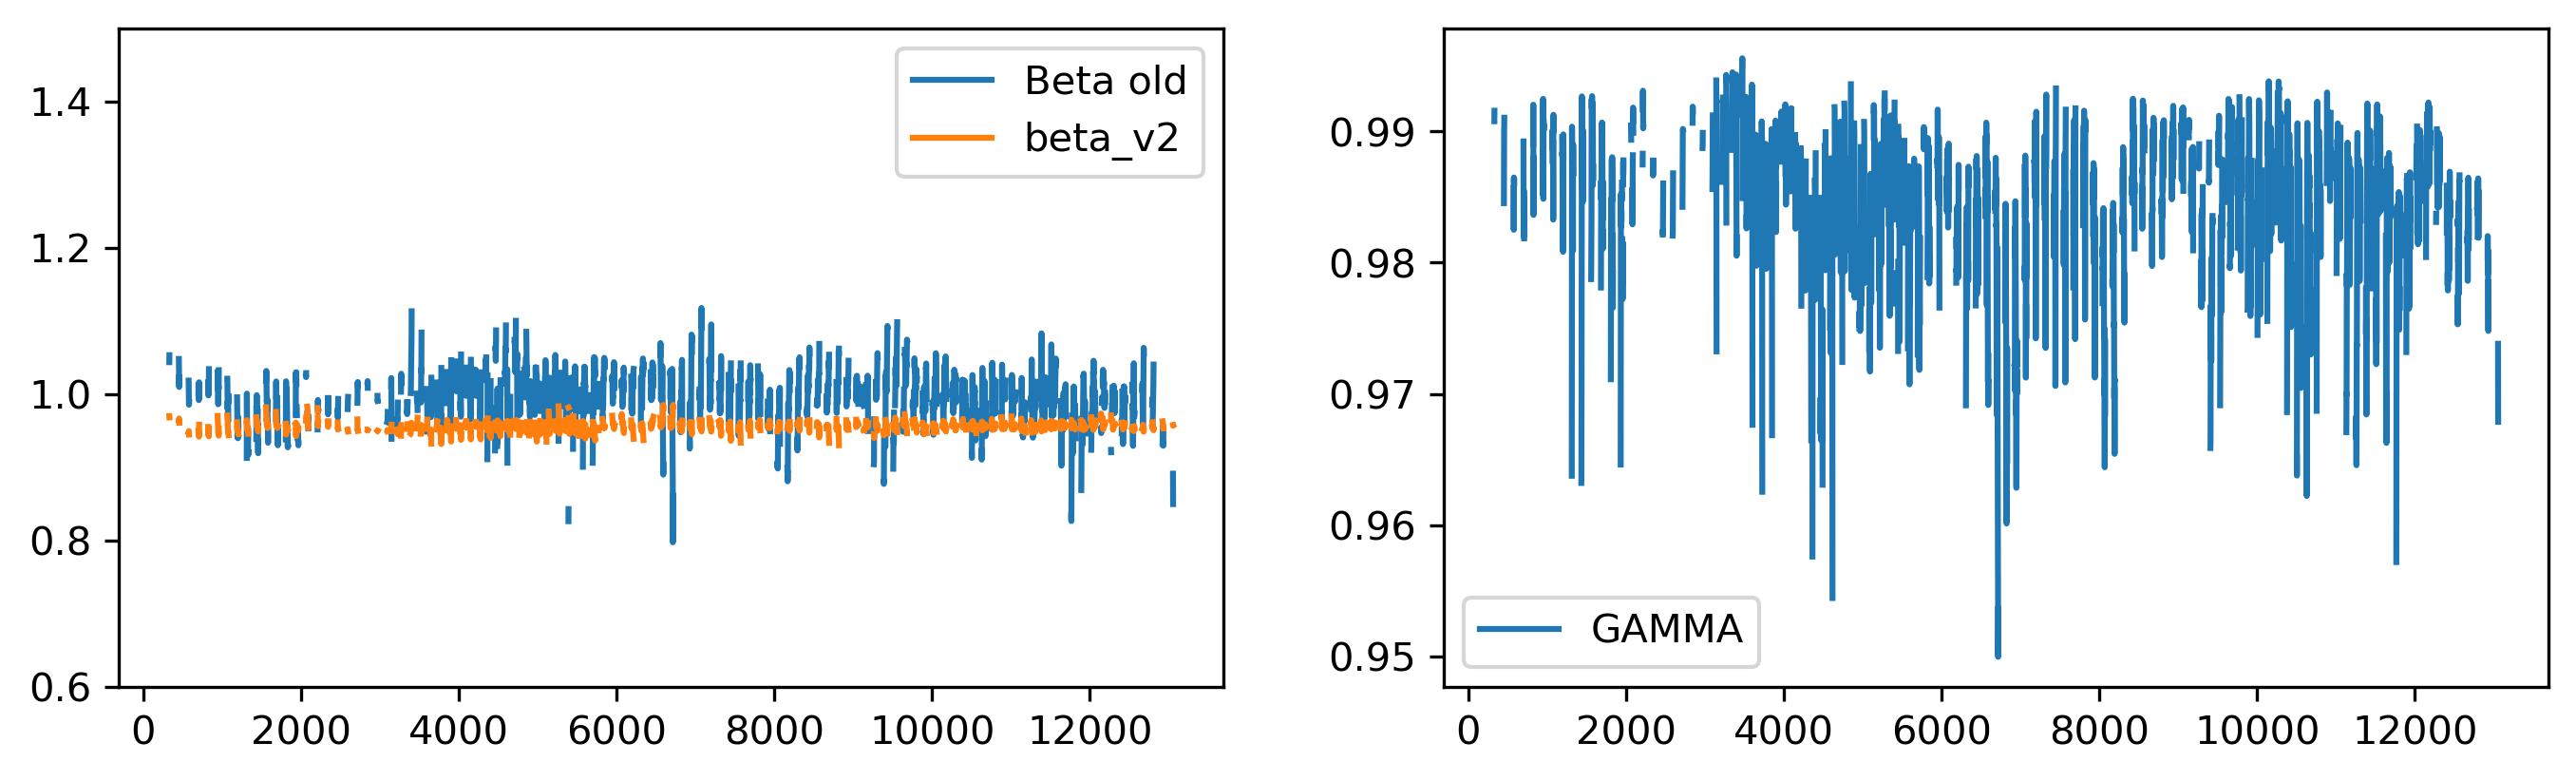

In [39]:
# i,j = 3,80
i,j = pos_x[2],pos_y[3]

fig = plt.figure(figsize=(11,3),dpi=300)
gs = gridspec.GridSpec(1,2)

# ========================================================================================================
ax1 = plt.subplot(gs[0, 0])
ax1.plot(BETA_old.flatten(), label='Beta old')
ax1.plot(BETA_new.flatten()-0.05, label=f'{beta_version}')
ax1.legend()
ax1.set_ylim(0.6,1.5)

# ========================================================================================================
ax1 = plt.subplot(gs[0, 1])
ax1.plot(GAMMA.flatten(), label='GAMMA')
ax1.legend()

In [40]:
Gev_levels = np.arange(20, 320, 20)
Gev_cmap = plt.cm.Spectral_r
norm = BoundaryNorm(Gev_levels, ncolors=Gev_cmap.N, clip=True)

Diff_levels = np.arange(-40, 45, 5)
Diff_cmap = plt.cm.coolwarm_r
Diff_norm = BoundaryNorm(Diff_levels, ncolors=Diff_cmap.N, clip=True)

In [41]:
pos = 3

Export figure to: ../../figures/corrected/Quantiles_GSMaP_GEV_raw_50yrs.png


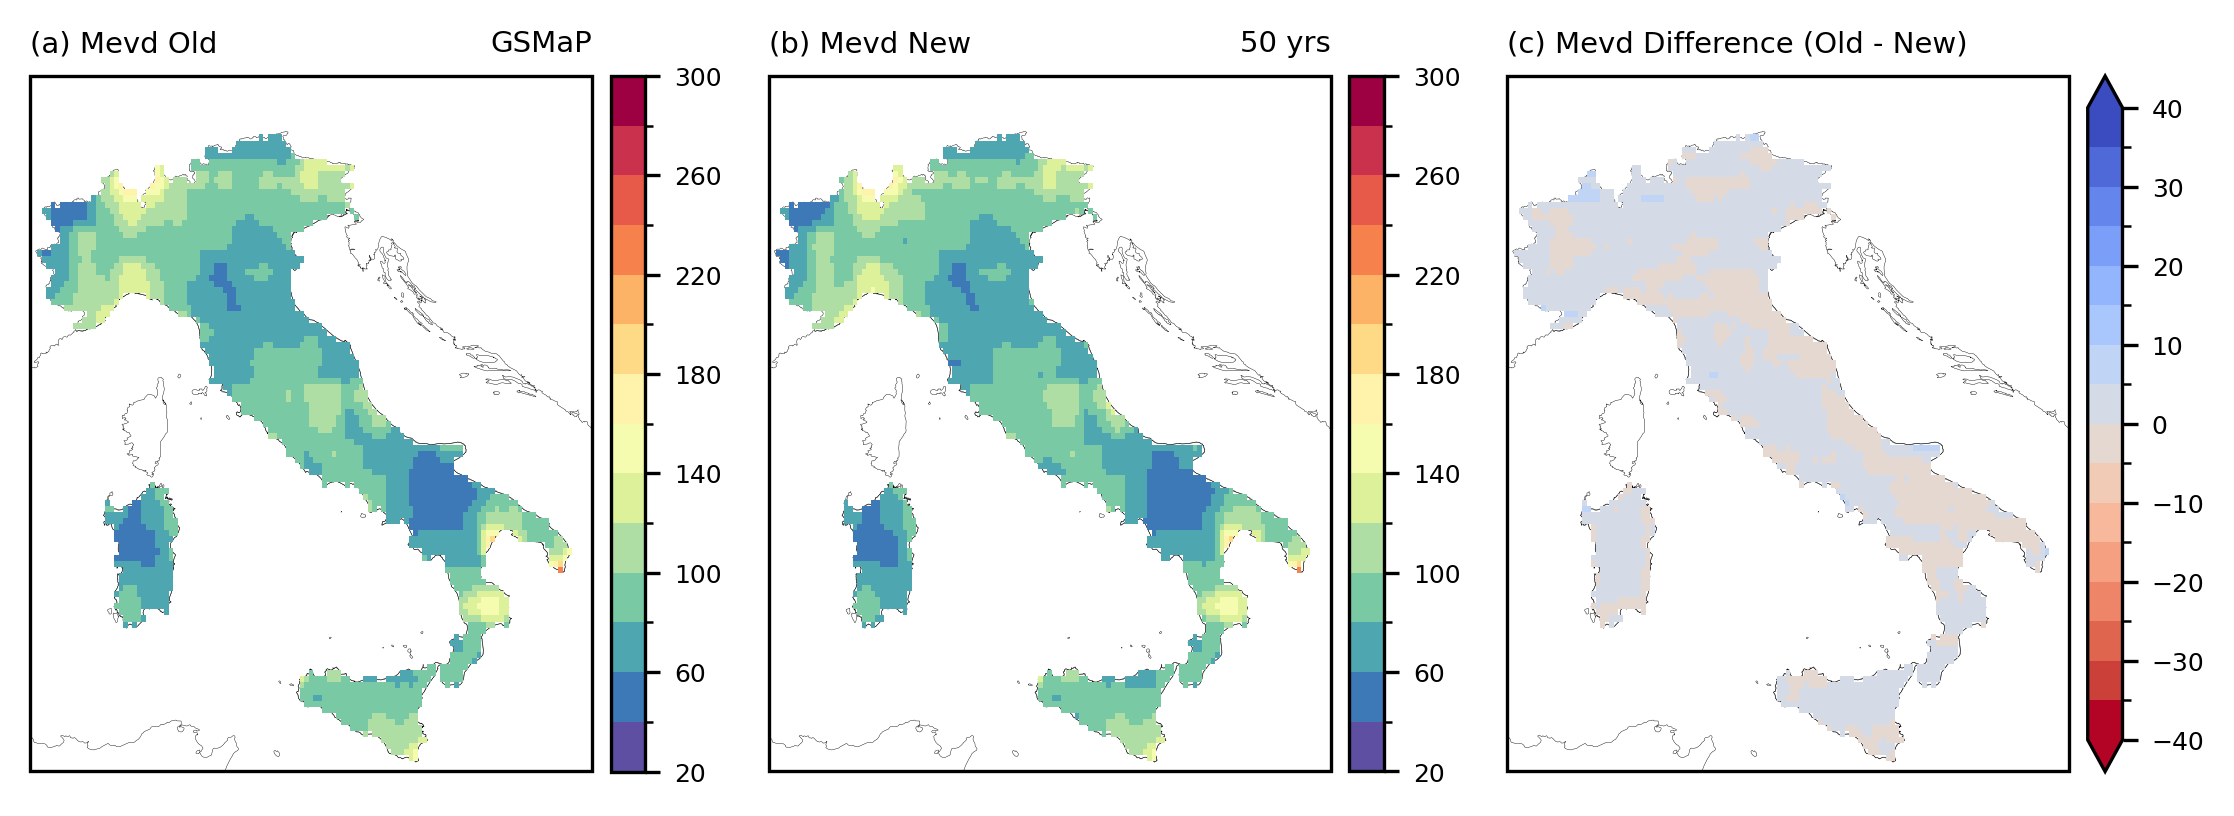

In [42]:
proj = ccrs.PlateCarree()

fig = plt.figure(figsize=(9,5),dpi=300)
gs = gridspec.GridSpec(1,3)

# ========================================================================================================
ax1 = plt.subplot(gs[0, 0], projection = proj)
ax1.set_extent([lon_min, lon_max, lat_min, lat_max], crs=proj)
ax1.add_feature(cfeature.COASTLINE,linewidth=0.1,edgecolor='k')
GEOMETRY.plot(legend=False, facecolor="none", edgecolor='black', linewidth=0.1, ax=ax1, zorder=10)
a1 = ax1.pcolormesh(lon2d, lat2d, Mevd_old[pos,:,:],cmap=Gev_cmap,norm=norm, zorder=10)

cbar = plt.colorbar(a1, fraction=0.0565, pad=0.03)
cbar.ax.tick_params(labelsize=6)

ax1.set_title('(a) Mevd Old', loc='left', fontsize=7)
ax1.set_title(product, loc='right', fontsize=7)

# ========================================================================================================
ax1 = plt.subplot(gs[0, 1], projection = proj)
ax1.set_extent([lon_min, lon_max, lat_min, lat_max], crs=proj)
ax1.add_feature(cfeature.COASTLINE,linewidth=0.1,edgecolor='k')
GEOMETRY.plot(legend=False, facecolor="none", edgecolor='black', linewidth=0.1, ax=ax1, zorder=10)
a1 = ax1.pcolormesh(lon2d, lat2d, Mevd[pos,:,:],cmap=Gev_cmap,norm=norm, zorder=10)

cbar = plt.colorbar(a1, fraction=0.0565, pad=0.03)
cbar.ax.tick_params(labelsize=6)

ax1.set_title('(b) Mevd New', loc='left', fontsize=7)
ax1.set_title(f'{Tr[pos]} yrs', loc='right', fontsize=7)

# ========================================================================================================
ax1 = plt.subplot(gs[0, 2], projection = proj)
ax1.set_extent([lon_min, lon_max, lat_min, lat_max], crs=proj)
ax1.add_feature(cfeature.COASTLINE,linewidth=0.1,edgecolor='k')
GEOMETRY.plot(legend=False, facecolor="none", edgecolor='black', linewidth=0.1, ax=ax1, zorder=10)
a1 = ax1.pcolormesh(lon2d, lat2d, Mevd_old[pos,:,:]-Mevd[pos,:,:],cmap=Diff_cmap,norm=Diff_norm, zorder=10)

cbar = plt.colorbar(a1, fraction=0.0565, pad=0.03, extend='both')
cbar.ax.tick_params(labelsize=6)

ax1.set_title('(c) Mevd Difference (Old - New)', loc='left', fontsize=7)

# ===========================================================================================================================================================================
# ===========================================================================================================================================================================
# cbar_ax = fig.add_axes([0.96, 0.18, 0.025, 0.64]) # Horizontal
# cbar = fig.colorbar(a1, cax=cbar_ax, orientation='vertical')
# cbar.ax.tick_params(labelsize=8)
# cbar.set_label(f"MEV {Tr[pos]}-years Corrected Quantiles (mm/day)", fontsize=8, labelpad=9)

# plt.subplots_adjust(left=0.05, bottom=0.05, right=0.95, top=0.95, wspace=0.06, hspace=0.1)

salida = os.path.join('..','..','figures','corrected',f'Quantiles_{product}_GEV_raw_{Tr[pos]}yrs.png')
print(f'Export figure to: {salida}')
# plt.savefig(salida,transparent = False,bbox_inches ='tight',pad_inches = 0.1, facecolor=None)

In [43]:
BETA_old_list = BETA_old[~np.isnan(BETA_old)]
BETA_new_list = BETA_new[~np.isnan(BETA_new)]

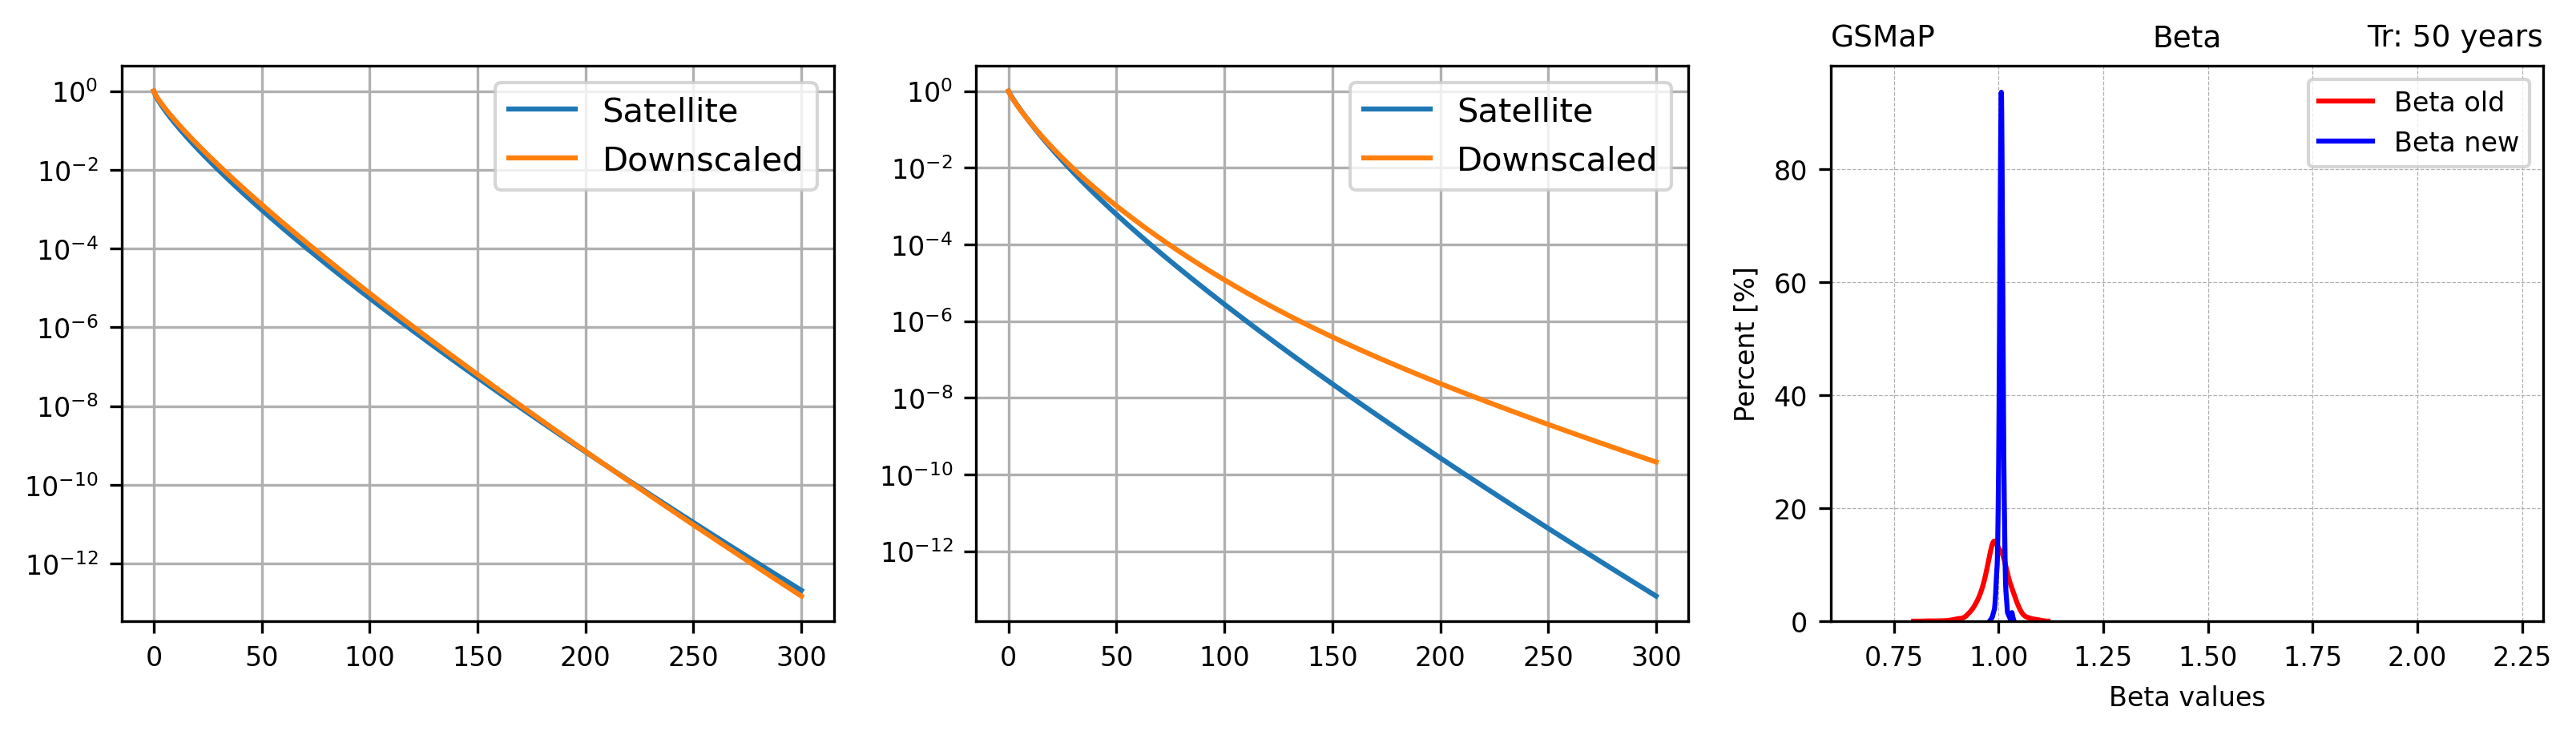

In [44]:
fig = plt.figure(figsize=(13,3),dpi=300)
gs = gridspec.GridSpec(1,3)

# ========================================================================================================
ax1 = plt.subplot(gs[0, 0])
ii = 0
x = np.linspace(0,300,5000)
sf_sat  = 1 - weibull_min.cdf(x,c=Ws[ii],scale=Cs[ii])
sf_down = 1 - weibull_min.cdf(x,c=Wd[ii],scale=Cd[ii])

ax1.semilogy(x,sf_sat,label='Satellite')
ax1.semilogy(x,sf_down,label='Downscaled')
ax1.legend()
ax1.grid(True)
ax1.tick_params(axis='both', which='major', labelsize=8)

# ========================================================================================================
ax1 = plt.subplot(gs[0, 1])
x = np.linspace(0,300,5000)
sf_sat = np.zeros((len(Ws),len(x)))
sf_down = np.zeros((len(Wd),len(x)))

for i in range(len(Ws)):
    sf_sat[i,:] = 1-weibull_min.cdf(x,c=Ws[i],scale=Cs[i])
    sf_down[i,:] = 1-weibull_min.cdf(x,c=Wd[i],scale=Cd[i])

sf_sat_mean = sf_sat.mean(axis=0)
sf_down_mean = sf_down.mean(axis=0)

ax1.semilogy(x,sf_sat_mean,label='Satellite')
ax1.semilogy(x,sf_down_mean,label='Downscaled')
ax1.legend()
ax1.grid(True)
ax1.tick_params(axis='both', which='major', labelsize=8)

# ==========================================================================================================================
ax1 = plt.subplot(gs[0, 2])

sns.kdeplot(BETA_old_list,color='r',cumulative=False,fill=False,multiple="stack",ax=ax1,label=f'Beta old',
            clip=(np.nanmin(np.array(BETA_old_list)), np.nanmax(np.array(BETA_old_list))))

sns.kdeplot(BETA_new_list,color='b',cumulative=False,fill=False,multiple="stack",ax=ax1,label=f'Beta new',
            clip=(np.nanmin(np.array(BETA_new_list)), np.nanmax(np.array(BETA_new_list))))

ax1.legend(fontsize=8, loc=1, ncol=1)
ax1.grid(linewidth=0.3, linestyle='--')
ax1.set_xlim(0.6, 2.3)
ax1.set_ylabel('Percent [%]',fontsize=8)
ax1.set_xlabel('Beta values',fontsize=8)

ax1.set_title(product, fontsize=9, loc='left')
ax1.set_title('Beta', fontsize=9, loc='center')
ax1.set_title(f'Tr: {Tr[pos]} years', fontsize=9, loc='right')
ax1.tick_params(axis='both', which='major', labelsize=8)

In [45]:
desc = DATA_small.description.replace('\n', ' ')
desc = ' '.join(DATA_small.description.split())

DOWN_xr = xr.Dataset(data_vars={
                    "NYs": (("year","lat","lon"), DATA_small.NYs.values),
                    "CYs": (("year","lat","lon"), DATA_small.CYs.values),
                    "WYs": (("year","lat","lon"), DATA_small.WYs.values),
                    "Mev_s": (("Tr","lat","lon"), DATA_small.Mev_s.values),
                    "NYd": (("year","lat","lon"), NYd),
                    "CYd": (("year","lat","lon"), CYd),
                    "WYd": (("year","lat","lon"), WYd),
                    "Mev_d": (("Tr","lat","lon"), Mevd),
                    "BETA": (("lat","lon"), BETA_new),
                    "GAMMA": (("lat","lon"), DATA_small.GAMMA.values),
                    "FUNVAL": (("lat","lon"), DATA_small.FUNVAL.values)
                    },
    coords={'year':DATA_small.year.values,'Tr':Tr,'lat': lats, 'lon': lons},
    attrs=dict(description=desc))

DOWN_xr.NYs.attrs["units"] = "day"
DOWN_xr.NYs.attrs["long_name"] = "Number of wet days"
DOWN_xr.NYs.attrs["origname"] = "Wet days"

DOWN_xr.CYs.attrs["units"] = "dimensionless"
DOWN_xr.CYs.attrs["long_name"] = "Weibull scale parameter"
DOWN_xr.CYs.attrs["origname"] = "Scale"

DOWN_xr.WYs.attrs["units"] = "dimensionless"
DOWN_xr.WYs.attrs["long_name"] = "Weibull shape parameter"
DOWN_xr.WYs.attrs["origname"] = "Shape"

DOWN_xr.Mev_s.attrs["units"] = "mm/day"
DOWN_xr.Mev_s.attrs["long_name"] = "Satellite Maximum Annual Daily"
DOWN_xr.Mev_s.attrs["origname"] = "Satellite quantiles"

DOWN_xr.NYd.attrs["units"] = "day"
DOWN_xr.NYd.attrs["long_name"] = "Downscale Number of wet days"
DOWN_xr.NYd.attrs["origname"] = "Down wet days"

DOWN_xr.CYd.attrs["units"] = "dimensionless"
DOWN_xr.CYd.attrs["long_name"] = "Downscale Weibull scale parameter"
DOWN_xr.CYd.attrs["origname"] = "Down scale"

DOWN_xr.WYd.attrs["units"] = "dimensionless"
DOWN_xr.WYd.attrs["long_name"] = "Downscale Weibull shape parameter"
DOWN_xr.WYd.attrs["origname"] = "Down shape"

DOWN_xr.Mev_d.attrs["units"] = "mm/day"
DOWN_xr.Mev_d.attrs["long_name"] = "Downscaling Maximum Annual Daily"
DOWN_xr.Mev_d.attrs["origname"] = "Downscaling quantiles"

DOWN_xr.BETA.attrs["units"] = "dimensionless"
DOWN_xr.BETA.attrs["long_name"] = "Itermittency function between two generic scales"
DOWN_xr.BETA.attrs["origname"] = "Beta"

DOWN_xr.GAMMA.attrs["units"] = "dimensionless"
DOWN_xr.GAMMA.attrs["long_name"] = "Variance function between two generic scales"
DOWN_xr.GAMMA.attrs["origname"] = "Gamma"

DOWN_xr.FUNVAL.attrs["units"] = "dimensionless"
DOWN_xr.FUNVAL.attrs["long_name"] = "Minimum error achieved by the optimization"
DOWN_xr.FUNVAL.attrs["origname"] = "Funval"

DOWN_xr.lat.attrs["units"] = "degrees_north"
DOWN_xr.lat.attrs["long_name"] = "Latitude"

DOWN_xr.lon.attrs["units"] = "degrees_east"
DOWN_xr.lon.attrs["long_name"] = "Longitude"

In [46]:
dir_out = os.path.join(dir_base,'uncorrected',beta_version,f'ITALY_DOWN_{product}_{time_reso}_2002_2023_npix_{npix}_thr_1_acf_mar_genetic_pearson.nc')
print(f'Export Data to {dir_out}')
DOWN_xr.to_netcdf(dir_out)

Export Data to /media/arturo/T9/Data/Italy/Satellite/2_MEV/uncorrected/beta_v2/ITALY_DOWN_GSMaP_3h_2002_2023_npix_4_thr_1_acf_mar_genetic_pearson.nc
